In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy import sparse

import gseapy as gp
import networkx as nx
import matplotlib.pyplot as plt
import os
import re



In [4]:
group_files = {
    # ===== HC =====
    "HC_EMP":            "./adatas/adata_HC_EMP.h5ad",
    "HC_HSC":            "./adatas/adata_HC_HSC.h5ad",
    "HC_NK":             "./adatas/adata_HC_NK.h5ad",
    "HC_GMP1":            "./adatas/adata_HC_GMP1.h5ad",
    "HC_cDC1":           "./adatas/adata_HC_cDC1.h5ad",
    "HC_macrophage3":    "./adatas/adata_HC_macrophage3.h5ad",
    "HC_Erythroid(right)":"./adatas/adata_HC_Erythroid.h5ad",

    # ===== pre_res =====
    "pre_res_MPPCLP1":   "./adatas/adata_pre_res_MPPCLP1.h5ad",
    "pre_res_HSCLSC":    "./adatas/adata_pre_res_HSCLSC.h5ad",
    "pre_res_EMP":       "./adatas/adata_pre_res_EMP.h5ad",
    "pre_res_MPPCLP2":   "./adatas/adata_pre_res_MPPCLP2.h5ad",
    "pre_res_LE":        "./adatas/adata_pre_res_LE.h5ad",
    "pre_res_GMP1":      "./adatas/adata_pre_res_GMP1.h5ad",
    "pre_res_GMP2":      "./adatas/adata_pre_res_GMP2.h5ad",
    "pre_res_macrophage2":"./adatas/adata_pre_res_macrophage2.h5ad",
    "pre_res_Erythroid(right)":"./adatas/adata_pre_res_Erythroid.h5ad",

    # ===== pre_nres =====
    "pre_nres_HSCLSC":   "./adatas/adata_pre_nres_HSCLSC.h5ad",
    "pre_nres_MPPCLP1":  "./adatas/adata_pre_nres_MPPCLP1.h5ad",
    "pre_nres_EMP":      "./adatas/adata_pre_nres_EMP.h5ad",
    "pre_nres_LE":       "./adatas/adata_pre_nres_LE.h5ad",
    "pre_nres_Erythroid(right)":"./adatas/adata_pre_nres_Erythroid.h5ad",

    # ===== post_res =====
    "post_res_EMP":      "./adatas/adata_post_res_EMP.h5ad",
    "post_res_LE":       "./adatas/adata_post_res_LE.h5ad",
    "post_res_GMP1":     "./adatas/adata_post_res_GMP1.h5ad",
    "post_res_Erythroid(right)":"./adatas/adata_post_res_Erythroid.h5ad",

    # ===== post_nres =====
    "post_nres_ASDC":        "./adatas/adata_post_nres_ASDC.h5ad",
    "post_nres_MPPpreB":     "./adatas/adata_post_nres_MPPpreB.h5ad",
    "post_nres_HSCLSC":      "./adatas/adata_post_nres_HSCLSC.h5ad",
    "post_nres_MPPCLP1":      "./adatas/adata_post_nres_MPPCLP1.h5ad",
    "post_nres_EMP":         "./adatas/adata_post_nres_EMP.h5ad",
    "post_nres_Macrophage1": "./adatas/adata_post_nres_Macrophage1.h5ad",
    "post_nres_LE":          "./adatas/adata_post_nres_LE.h5ad",
    "post_nres_GMP1":        "./adatas/adata_post_nres_GMP1.h5ad",
    "post_nres_Erythroid(right)":"./adatas/adata_post_nres_Erythroid.h5ad",
}

# 读入
adatas = {g: sc.read_h5ad(f) for g, f in group_files.items()}


# =========================
# 0) 你的数据（已读入可跳过）
# =========================
# group_files = {...}
# adatas = {g: sc.read_h5ad(f) for g, f in group_files.items()}

# =========================
# 1) 你要比较的 pairs（g1 vs g2）
# =========================

# pairs = [
#     ("pre_res_HSCLSC",   "pre_nres_HSCLSC"),
#     ("pre_res_EMP",      "pre_nres_EMP"),
#     ("pre_res_MPPCLP1",  "pre_nres_MPPCLP1"),
# ]

# pairs = [
#     ("pre_nres_HSCLSC",   "pre_res_HSCLSC"),
#     ("pre_nres_EMP",      "pre_res_EMP"),
#     ("pre_nres_MPPCLP1",  "pre_res_MPPCLP1"),
# ]
# pairs = [
#     ("post_nres_HSCLSC",   "pre_nres_HSCLSC"),
#     ("post_nres_EMP",      "pre_nres_EMP"),
#     ("post_nres_MPPCLP1",  "pre_nres_MPPCLP1"),
# ]
pairs = [
    ("pre_nres_HSCLSC",   "post_nres_HSCLSC"),
    ("pre_nres_EMP",      "post_nres_EMP"),
    ("pre_nres_MPPCLP1",  "post_nres_MPPCLP1"),
]

Saved full results: positive_only_ALLGENES_full_results.csv
Saved significant up-in-g2: positive_only_sig_up_in_g2.csv
Rows kept after MIN_POS_CELLS filtering: 16402
Significant & up in g2: 430

== pre_nres_EMP vs post_nres_EMP ==
  enrich total terms: 1526
  after padj<0.05: 48
  terms kept for network (hit fc genes): 10


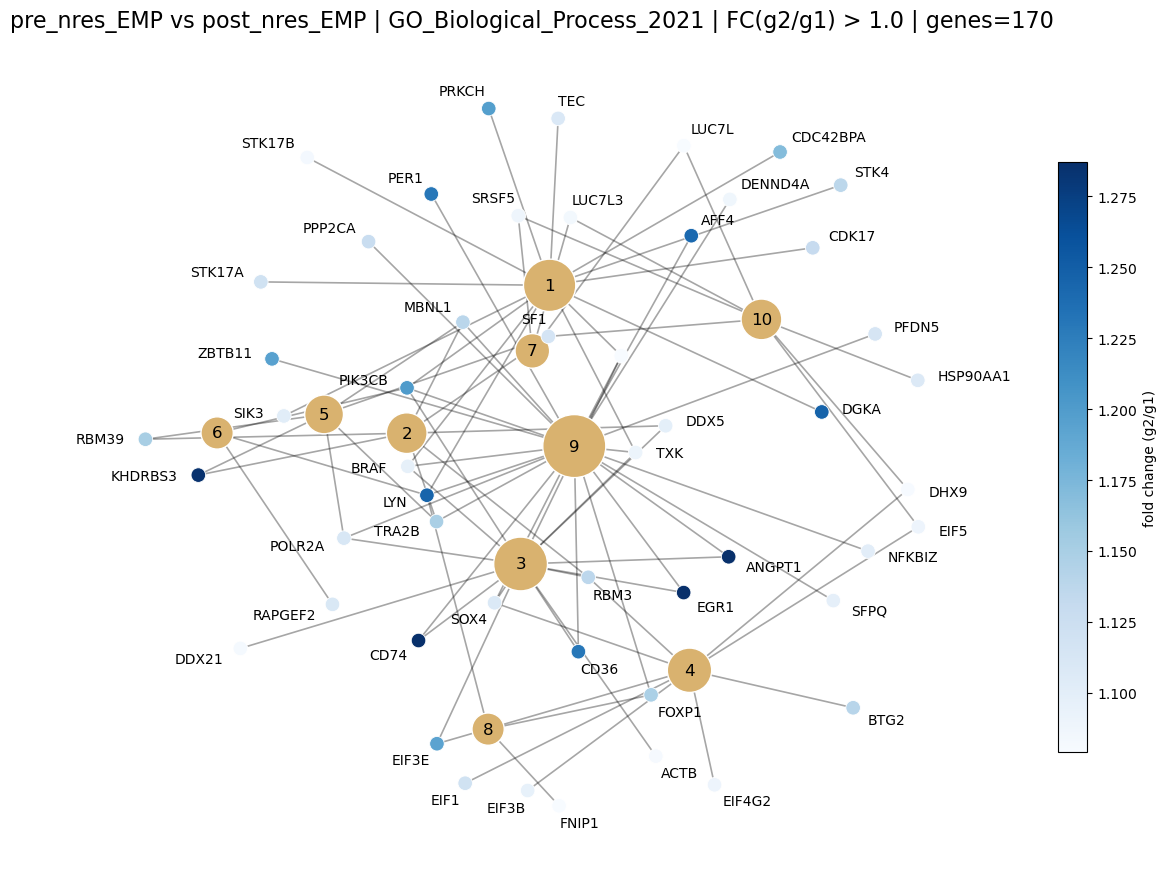

 GO_id                                            GO_term  n_hit_genes  Adjusted_P_value
     1                                    phosphorylation           14          0.008367
     2       regulation of mRNA splicing, via spliceosome            7          0.008367
     3             positive regulation of gene expression           15          0.008367
     4                          regulation of translation            9          0.008430
     5                         regulation of RNA splicing            6          0.014082
     6 positive regulation of leukocyte apoptotic process            3          0.021327
     7                         mRNA splice site selection            4          0.021327
     8             regulation of B cell apoptotic process            3          0.021327
     9                      regulation of gene expression           22          0.021327
    10                 ribonucleoprotein complex assembly            7          0.024417
  saved GO id map: ge

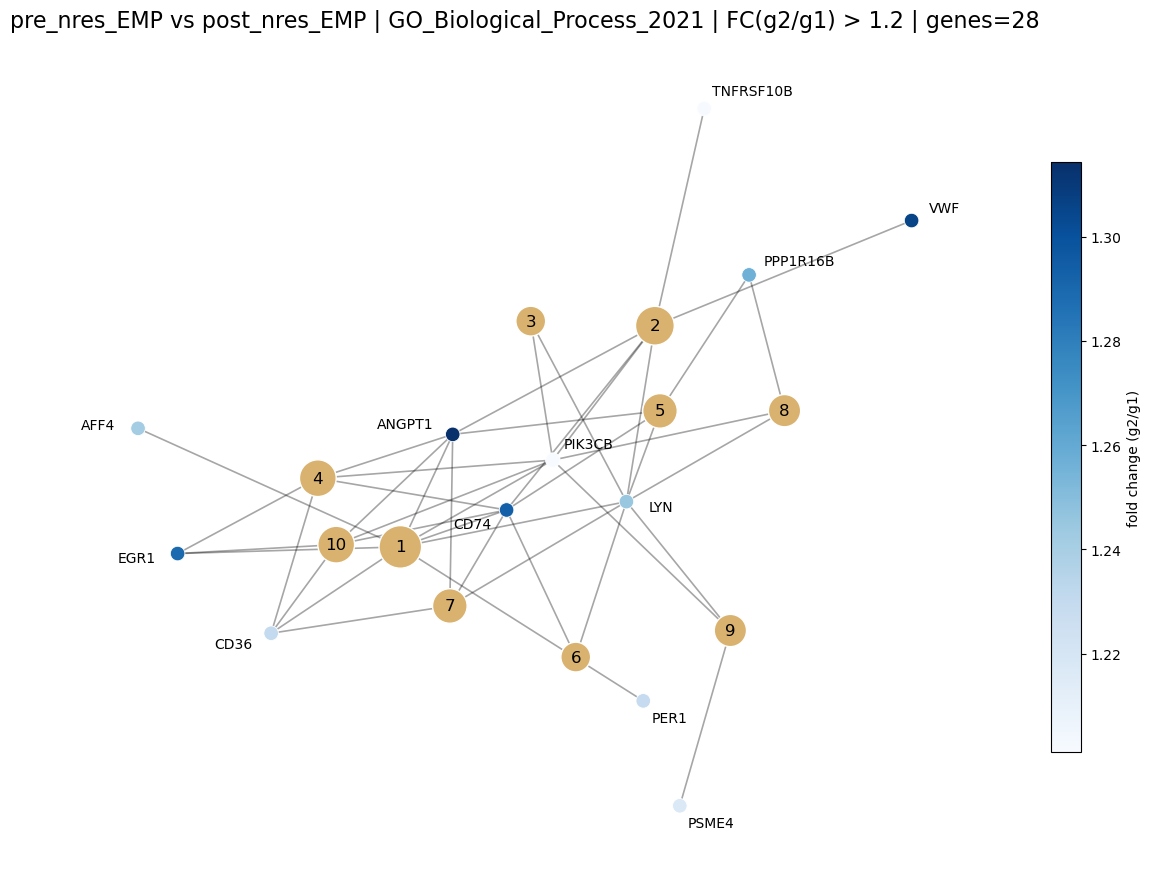

 GO_id                                                  GO_term  n_hit_genes  Adjusted_P_value
     1                            regulation of gene expression            8          0.019494
     2 positive regulation of intracellular signal transduction            6          0.019494
     3       positive regulation of leukocyte apoptotic process            2          0.019494
     4   positive regulation of macromolecule metabolic process            5          0.021174
     5      positive regulation of protein modification process            4          0.021174
     6                       regulation of leukocyte activation            2          0.021174
     7                      regulation of ERK1 and ERK2 cascade            4          0.025905
     8    regulation of phosphatidylinositol 3-kinase signaling            3          0.026066
     9                    Fc-epsilon receptor signaling pathway            3          0.026066
    10                   positive regulation of ge

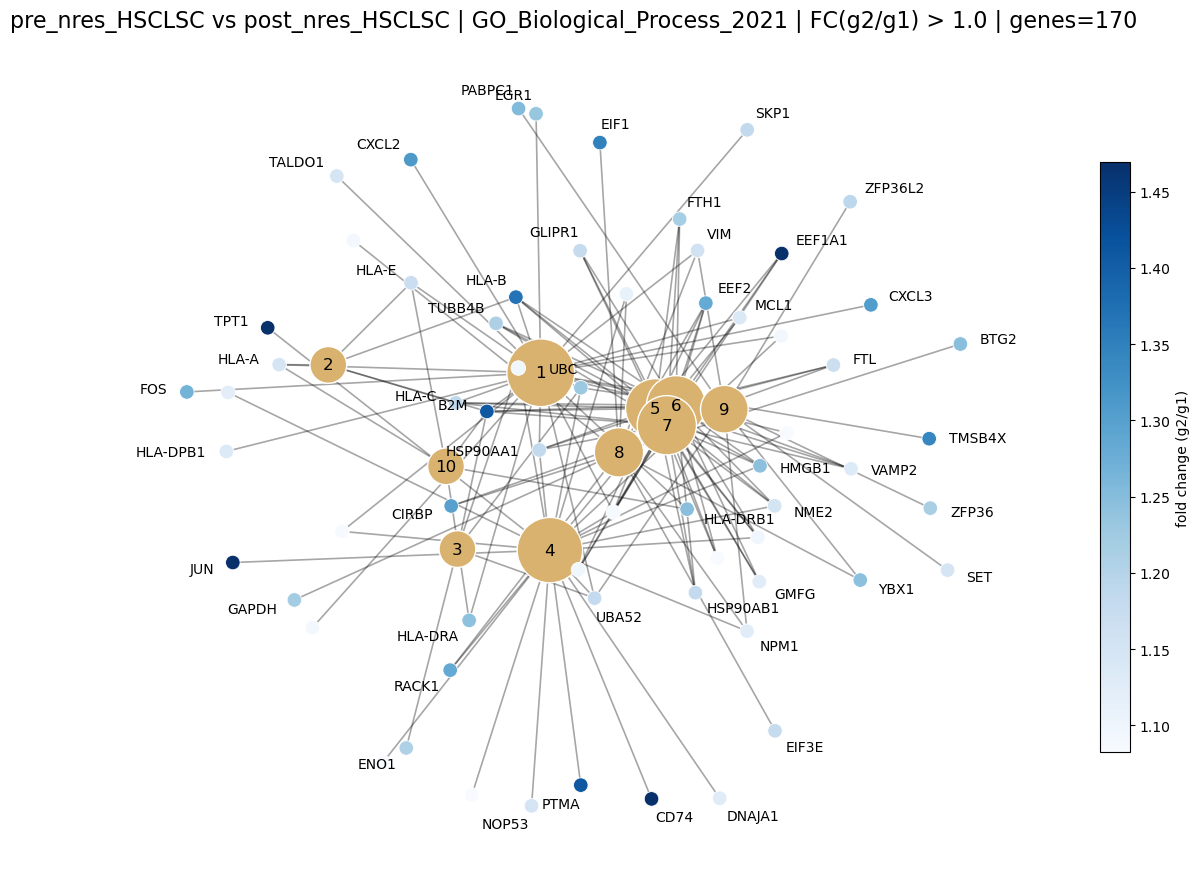

 GO_id                                                                                           GO_term  n_hit_genes  Adjusted_P_value
     1                                                               cytokine-mediated signaling pathway           26      3.097662e-08
     2 antigen processing and presentation of exogenous peptide antigen via MHC class I, TAP-independent            5      1.951316e-06
     3                                                            modulation by symbiont of host process            5      5.773913e-06
     4                                                                   regulation of apoptotic process           24      8.141834e-06
     5                                                                          neutrophil degranulation           19      8.741565e-06
     6                                                                      neutrophil mediated immunity           19      8.741565e-06
     7                                          

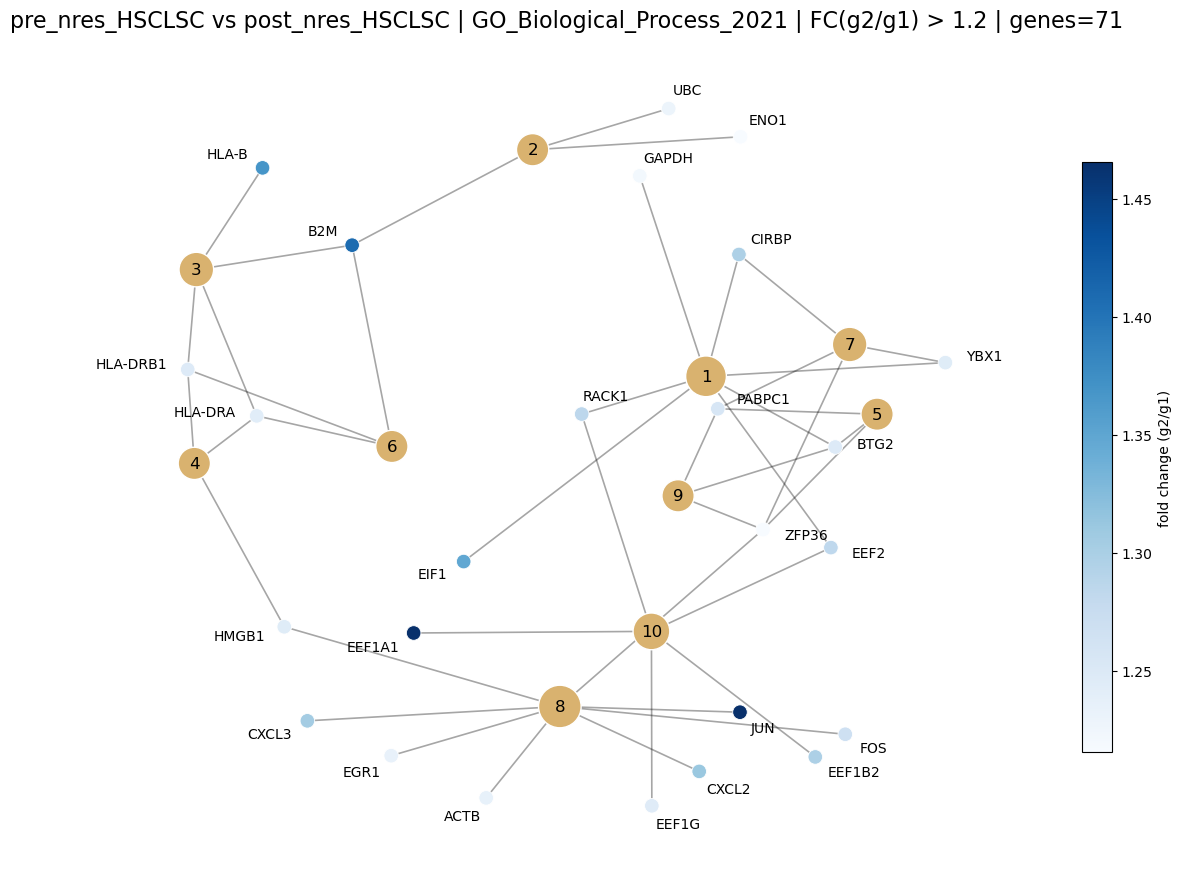

 GO_id                                                                 GO_term  n_hit_genes  Adjusted_P_value
     1                                               regulation of translation            7          0.001946
     2                                  modulation by symbiont of host process            3          0.001946
     3                         positive regulation of T cell mediated immunity            4          0.001946
     4           regulation of CD4-positive, alpha-beta T cell differentiation            3          0.001946
     5 positive regulation of nuclear-transcribed mRNA poly(A) tail shortening            3          0.001946
     6       antigen processing and presentation of endogenous peptide antigen            3          0.001946
     7                                                      mRNA stabilization            4          0.001946
     8                         cellular response to oxygen-containing compound            8          0.001946
     9    

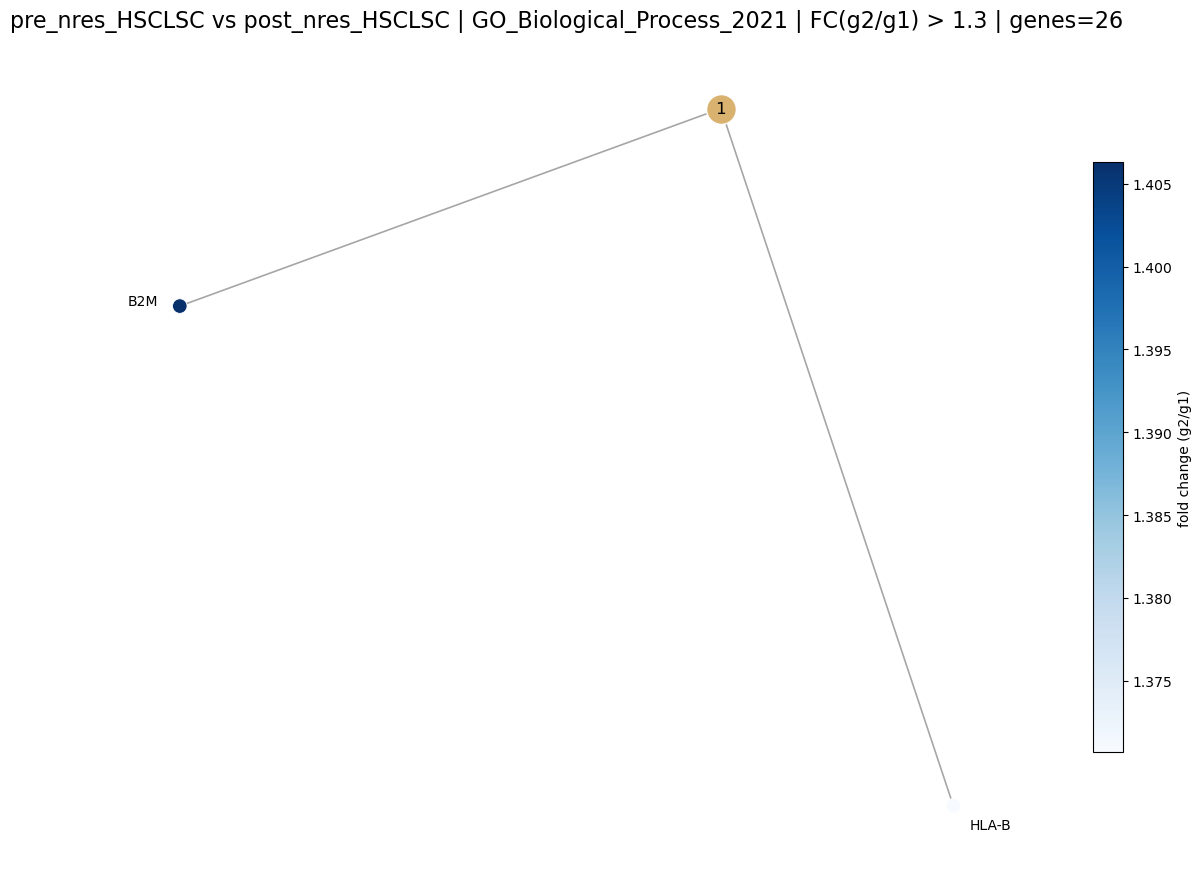

 GO_id                                                                                           GO_term  n_hit_genes  Adjusted_P_value
     1 antigen processing and presentation of exogenous peptide antigen via MHC class I, TAP-independent            2          0.014671
  saved GO id map: gene_go_networks\GO_id_map_pre_nres_HSCLSC_vs_post_nres_HSCLSC_FCgt1p3.csv

== pre_nres_MPPCLP1 vs post_nres_MPPCLP1 ==
  enrich total terms: 1265
  after padj<0.05: 238
  terms kept for network (hit fc genes): 10


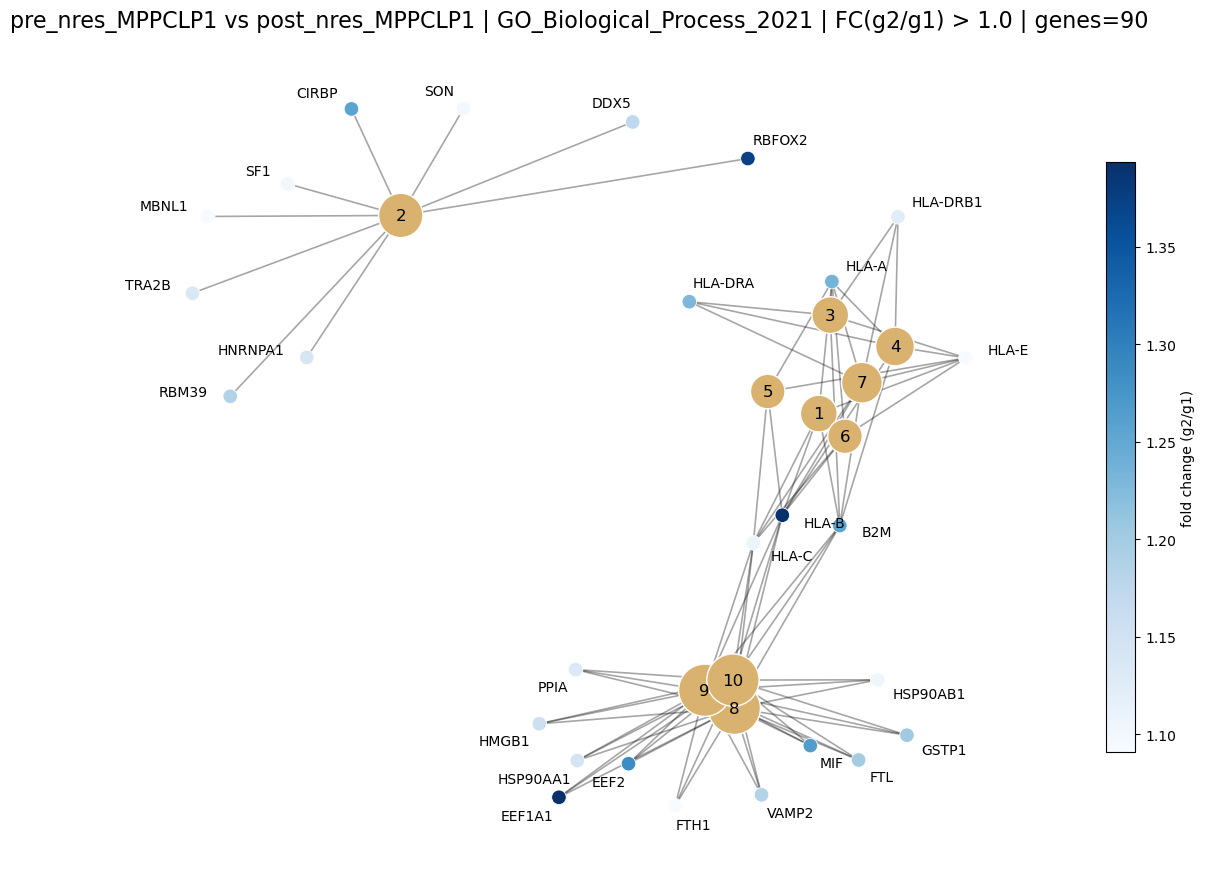

 GO_id                                                                                                           GO_term  n_hit_genes  Adjusted_P_value
     1                 antigen processing and presentation of exogenous peptide antigen via MHC class I, TAP-independent            5      1.155432e-07
     2                                                                      regulation of mRNA splicing, via spliceosome            9      1.665703e-07
     3                                                 antigen processing and presentation of endogenous peptide antigen            5      1.347988e-06
     4                                                                   positive regulation of T cell mediated immunity            6      2.799585e-06
     5                  antigen processing and presentation of endogenous peptide antigen via MHC class I via ER pathway            4      2.799585e-06
     6 antigen processing and presentation of endogenous peptide antigen via MHC class I

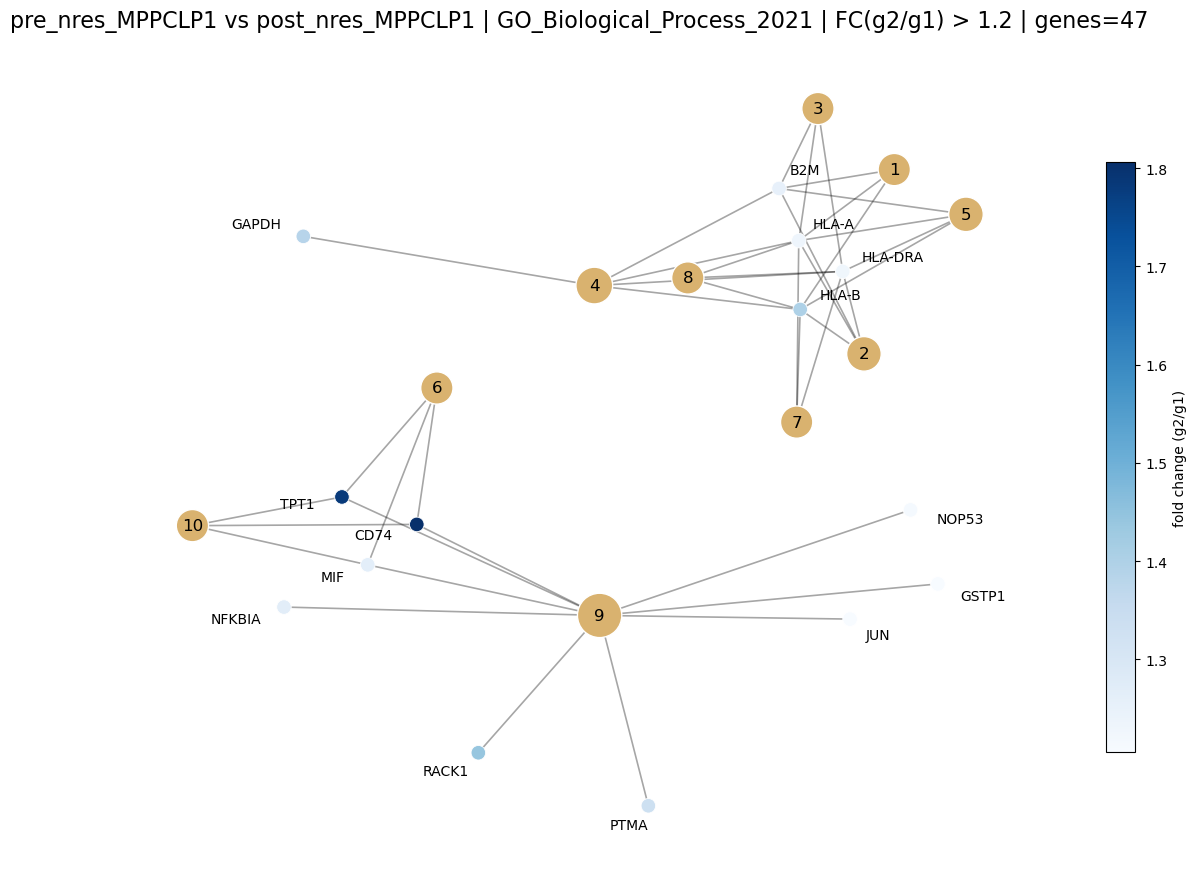

 GO_id                                                                                           GO_term  n_hit_genes  Adjusted_P_value
     1 antigen processing and presentation of exogenous peptide antigen via MHC class I, TAP-independent            3          0.000480
     2                                                   positive regulation of T cell mediated immunity            4          0.000530
     3                                 antigen processing and presentation of endogenous peptide antigen            3          0.001030
     4                                                             cellular response to interferon-gamma            5          0.001660
     5                                                       interferon-gamma-mediated signaling pathway            4          0.002776
     6            negative regulation of intrinsic apoptotic signaling pathway in response to DNA damage            3          0.003092
     7                                          

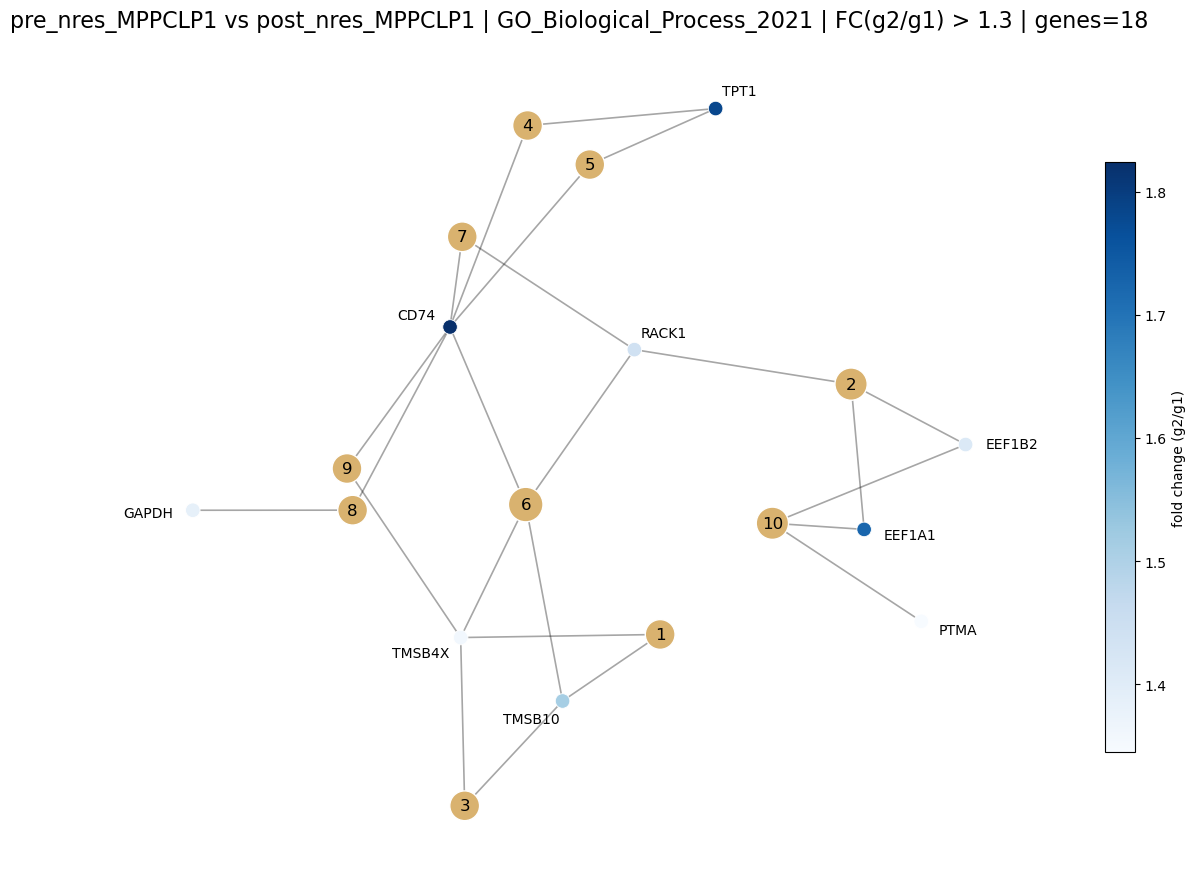

 GO_id                                                                                GO_term  n_hit_genes  Adjusted_P_value
     1                                                         sequestering of actin monomers            2          0.010729
     2                                                               translational elongation            3          0.016480
     3                                   negative regulation of actin filament polymerization            2          0.019208
     4 negative regulation of intrinsic apoptotic signaling pathway in response to DNA damage            2          0.019208
     5                                 negative regulation of response to DNA damage stimulus            2          0.021712
     6                                                           regulation of cell migration            4          0.021712
     7                                      regulation of cytokine-mediated signaling pathway            2          0.048680


In [5]:


# =========================
# 2) DEG 参数（保留你原设定）
# =========================
USE_LAYER = None
USE_RAW = False
THRESHOLD = 0.0
MIN_POS_CELLS = 20

USE_FDR = False
P_CUTOFF = 0.05
FDR_CUTOFF = 0.05

FC_METHOD = "mean"        # "mean" or "median"
FC_PSEUDOCOUNT = 0.0

OUT_FULL = "positive_only_ALLGENES_full_results.csv"
OUT_SIG  = "positive_only_sig_up_in_g2.csv"

# =========================
# 3) GO / 网络图 参数
# =========================
GO_SETS = ("GO_Biological_Process_2021",)  # 你也可以换 MF/CCKEGG_2021_Human
ORGANISM = "Human"
GO_CUTOFF = 0.05
TOP_TERMS = 20
PADJ_KEEP_GT = 0.05 
# 你需要的两个版本：FC>1.0 与 FC>1.3
FC_THRESHOLDS_FOR_NETWORK = (1.0,1.2,1.3)

# 输出图文件夹
FIG_DIR = "gene_go_networks"
os.makedirs(FIG_DIR, exist_ok=True)


# =========================
# 4) 工具函数（DEG）
# =========================
def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    qvals = np.full_like(pvals, np.nan, dtype=float)
    ok = np.isfinite(pvals)
    if ok.sum() == 0:
        return qvals
    pv = pvals[ok]
    order = np.argsort(pv)
    ranked = pv[order]
    m = len(ranked)
    q = ranked * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[order] = q
    qvals[ok] = out
    return qvals


def get_matrix_and_genes(adata, use_layer=None, use_raw=False):
    if use_raw:
        if adata.raw is None:
            return None, None
        X = adata.raw.X
        genes = np.asarray(adata.raw.var_names)
    elif use_layer is not None:
        if use_layer not in adata.layers:
            return None, None
        X = adata.layers[use_layer]
        genes = np.asarray(adata.var_names)
    else:
        X = adata.X
        genes = np.asarray(adata.var_names)

    if sparse.issparse(X):
        X = X.tocsr()
    else:
        X = np.asarray(X)
    return X, genes


def summary_stat(x, method="mean"):
    if method == "median":
        return float(np.median(x))
    return float(np.mean(x))


def conditional_mw_positive_only_allgenes_okonly(
    ad1, ad2, g1_name, g2_name,
    min_pos_cells=20, threshold=0.0,
    use_layer=None, use_raw=False,
    fc_method="mean",
    fc_pseudocount=0.0
):
    """
    对所有共有基因做 positive-only MWU：
      - 仅使用 >threshold 的细胞
      - 若任一组 positive cells < min_pos_cells：直接丢弃（不输出）
      - FC / log2FC 计算：g2/g1（基于 positive-only）
    """
    X1, genes1 = get_matrix_and_genes(ad1, use_layer=use_layer, use_raw=use_raw)
    X2, genes2 = get_matrix_and_genes(ad2, use_layer=use_layer, use_raw=use_raw)
    if X1 is None or X2 is None:
        return pd.DataFrame()

    common = np.intersect1d(genes1, genes2, assume_unique=False)
    if common.size == 0:
        return pd.DataFrame()

    idx1 = pd.Index(genes1).get_indexer(common)
    idx2 = pd.Index(genes2).get_indexer(common)

    X1c = X1[:, idx1]
    X2c = X2[:, idx2]

    rows = []
    for j, gene in enumerate(common):
        if sparse.issparse(X1c):
            x1_all = X1c[:, j].toarray().ravel()
            x2_all = X2c[:, j].toarray().ravel()
        else:
            x1_all = np.asarray(X1c[:, j]).ravel()
            x2_all = np.asarray(X2c[:, j]).ravel()

        x1_pos = x1_all[x1_all > threshold]
        x2_pos = x2_all[x2_all > threshold]

        if (x1_pos.size < min_pos_cells) or (x2_pos.size < min_pos_cells):
            continue

        u, p = mannwhitneyu(x1_pos, x2_pos, alternative="two-sided")

        stat_g1 = summary_stat(x1_pos, method=fc_method)
        stat_g2 = summary_stat(x2_pos, method=fc_method)

        denom = stat_g1 + fc_pseudocount
        numer = stat_g2 + fc_pseudocount
        fc = (numer / denom) if denom > 0 else np.nan
        log2fc = np.log2(fc) if (np.isfinite(fc) and fc > 0) else np.nan

        rows.append({
            "pair": f"{g1_name} vs {g2_name}",
            "gene": gene,
            "threshold": float(threshold),

            "p_value": float(p),
            "U": float(u),

            f"{g1_name}_n_pos": int(x1_pos.size),
            f"{g2_name}_n_pos": int(x2_pos.size),

            f"{fc_method}_g1_pos": float(stat_g1),
            f"{fc_method}_g2_pos": float(stat_g2),

            "FC_g2_over_g1": float(fc) if np.isfinite(fc) else np.nan,
            "log2FC_g2_over_g1": float(log2fc) if np.isfinite(log2fc) else np.nan,

            "median_pos_diff(g1-g2)": float(np.median(x1_pos) - np.median(x2_pos)),
            "mean_pos_diff(g1-g2)": float(np.mean(x1_pos) - np.mean(x2_pos)),
        })

    return pd.DataFrame(rows)


# =========================
# 5) GO enrichment + 网络绘图
# =========================
def run_go_enrichr(gene_list, gene_sets, organism="Human", cutoff=0.05):
    enr = gp.enrichr(
        gene_list=list(gene_list),
        gene_sets=list(gene_sets),
        organism=organism,
        cutoff=cutoff
    )
    res = enr.results.copy()
    # 兼容列名
    if "Adjusted P-value" not in res.columns:
        for c in res.columns:
            if "Adjusted" in c and "P" in c:
                res["Adjusted P-value"] = res[c]
                break
    if "Genes" not in res.columns:
        for c in res.columns:
            if c.lower() == "genes":
                res["Genes"] = res[c]
                break
    return res

def build_gene_go_network(
    enrich_df,
    fc_map,
    padj_cutoff=0.05,   # 先做 Adjusted P-value 过滤
    top_n=10            # 再取 top10
):
    # 1) 过滤 padj
    df = enrich_df.copy()
    if "Adjusted P-value" not in df.columns:
        raise ValueError("enrich_df 缺少 'Adjusted P-value' 列")

    df = df[df["Adjusted P-value"].notna() & (df["Adjusted P-value"] < padj_cutoff)].copy()

    # 如果过滤后为空，直接返回空网
    if df.shape[0] == 0:
        return nx.Graph(), [], [], df

    # 2) 按 padj 排序取 top_n
    df = df.sort_values("Adjusted P-value", ascending=True).head(top_n).copy()

    G = nx.Graph()
    term_nodes, gene_nodes = [], []

    for _, row in df.iterrows():
        term = row["Term"]
        genes_str = row.get("Genes", "")
        genes_all = [g.strip() for g in str(genes_str).replace(",", ";").split(";") if g.strip()]

        # 3) 只保留在 fc_map 里的 genes（你的 FC 阈值筛选基因）
        genes = [g for g in genes_all if g in fc_map]

        # ✅ 如果这个 GO term 在你的筛选基因里一个都没命中，就跳过（避免孤立节点）
        if len(genes) == 0:
            continue

        G.add_node(term, node_type="term", hit_genes=len(genes), padj=float(row["Adjusted P-value"]))
        term_nodes.append(term)

        for g in genes:
            if not G.has_node(g):
                G.add_node(g, node_type="gene", fc=float(fc_map[g]))
                gene_nodes.append(g)
            G.add_edge(term, g)

    return G, term_nodes, gene_nodes, df



def plot_gene_go_network(G, term_nodes, gene_nodes, title="", out_png=None, figsize=(12, 9)):
    plt.figure(figsize=figsize)

    pos = nx.spring_layout(G, k=0.7, seed=0)

    term_sizes = [300 + 80 * max(1, G.nodes[t].get("hit_genes", 1)) for t in term_nodes]

    gene_fc = np.array([G.nodes[g].get("fc", 1.0) for g in gene_nodes], dtype=float)
    if len(gene_fc) == 0:
        gene_fc = np.array([1.0])

    vmin = max(1.0, np.percentile(gene_fc, 5))
    vmax = max(vmin + 1e-6, np.percentile(gene_fc, 95))

    nx.draw_networkx_edges(G, pos, alpha=0.35, width=1.2)

    nx.draw_networkx_nodes(
        G, pos,
        nodelist=term_nodes,
        node_size=term_sizes,
        node_color="#D9B26F",
        edgecolors="white",
        linewidths=1.0
    )

    nodes = nx.draw_networkx_nodes(
        G, pos,
        nodelist=gene_nodes,
        node_size=110,
        node_color=[G.nodes[g].get("fc", 1.0) for g in gene_nodes],
        cmap=plt.cm.Blues,
        vmin=vmin,
        vmax=vmax,
        edgecolors="white",
        linewidths=0.6
    )

    # ===== 在 node 外侧放 gene label（径向外移）=====
    label_top_genes = 50  # 你之前已经有这个参数

    # ===== 1) 先画 GO term labels（保证不丢）=====
    # term_labels = {t: t for t in term_nodes}
    # nx.draw_networkx_labels(
    #     G, pos,
    #     labels=term_labels,
    #     font_size=10
    # )

    # ✅ GO term 用编号显示：1..N
    term_id_map = {t: i+1 for i, t in enumerate(term_nodes)}  # term -> id
    term_labels_num = {t: str(term_id_map[t]) for t in term_nodes}

    nx.draw_networkx_labels(
        G, pos,
        labels=term_labels_num,
        font_size=12,
        font_color="black"
    )

    # ===== 2) 再画 gene labels：只标 top genes，并移动到节点外侧 =====
    if label_top_genes and len(gene_nodes) > 0:
        top_genes = sorted(
            gene_nodes,
            key=lambda g: G.nodes[g].get("fc", 1.0),
            reverse=True
        )[:label_top_genes]

        # 网络中心（用于径向外移）
        cx = np.mean([pos[n][0] for n in G.nodes()])
        cy = np.mean([pos[n][1] for n in G.nodes()])

        offset = 0.05  # 0.03–0.08 自己调

        for g in top_genes:
            x, y = pos[g]
            dx, dy = x - cx, y - cy
            norm = np.hypot(dx, dy)
            if norm == 0:
                continue
            ux, uy = dx / norm, dy / norm

            lx = x + ux * offset
            ly = y + uy * offset

            plt.text(
                lx, ly, g,
                fontsize=10,
                ha="left" if ux > 0 else "right",
                va="center"
            )



    cbar = plt.colorbar(nodes, shrink=0.7)
    cbar.set_label("fold change (g2/g1)", rotation=90)

    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=300)
    plt.show()
    plt.close()

# =========================
# 6) 主流程：DEG + 输出 + Gene→GO 网络
# =========================
all_res = []
for g1, g2 in pairs:
    if g1 not in adatas or g2 not in adatas:
        raise KeyError(f"Missing group in adatas: {g1} or {g2}")

    df_pair = conditional_mw_positive_only_allgenes_okonly(
        adatas[g1], adatas[g2],
        g1, g2,
        min_pos_cells=MIN_POS_CELLS,
        threshold=THRESHOLD,
        use_layer=USE_LAYER,
        use_raw=USE_RAW,
        fc_method=FC_METHOD,
        fc_pseudocount=FC_PSEUDOCOUNT
    )
    all_res.append(df_pair)

res_df = pd.concat(all_res, ignore_index=True)

if res_df.shape[0] == 0:
    print("No genes passed MIN_POS_CELLS filter across all pairs.")
    res_df.to_csv(OUT_FULL, index=False)
    raise SystemExit

# FDR
res_df["FDR_BH"] = bh_fdr(res_df["p_value"].values)

# 显著筛选
if USE_FDR:
    sig_mask = res_df["FDR_BH"].notna() & (res_df["FDR_BH"] < FDR_CUTOFF)
else:
    sig_mask = res_df["p_value"].notna() & (res_df["p_value"] < P_CUTOFF)

# 方向：g2 上调（log2FC>0）
up_in_g2_mask = res_df["log2FC_g2_over_g1"].notna() & (res_df["log2FC_g2_over_g1"] > 0)
sig_up_df = res_df[sig_mask & up_in_g2_mask].copy()

# 保存 DEG
res_df.to_csv(OUT_FULL, index=False)
sig_up_df.to_csv(OUT_SIG, index=False)
print(f"Saved full results: {OUT_FULL}")
print(f"Saved significant up-in-g2: {OUT_SIG}")
print("Rows kept after MIN_POS_CELLS filtering:", res_df.shape[0])
print("Significant & up in g2:", sig_up_df.shape[0])

# =========================
# 7) 对每个 pair 画两套 Gene→GO 网络（FC>1.0 / FC>1.3）
# =========================
for pair_name, dfp in sig_up_df.groupby("pair"):
    # pair_name like "g1 vs g2"
    g1_name, g2_name = pair_name.split(" vs ")
    print(f"\n== {pair_name} ==")

    for fc_th in FC_THRESHOLDS_FOR_NETWORK:
        df_fc = dfp[dfp["FC_g2_over_g1"].notna() & (dfp["FC_g2_over_g1"] > fc_th)].copy()
        if df_fc.shape[0] < 5:
            print(f"  [FC>{fc_th}] genes too few: {df_fc.shape[0]} (skip)")
            continue

        genes = df_fc["gene"].astype(str).tolist()
        fc_map = dict(zip(df_fc["gene"].astype(str), df_fc["FC_g2_over_g1"].astype(float)))

        enr = run_go_enrichr(genes, gene_sets=GO_SETS, organism=ORGANISM, cutoff=GO_CUTOFF)
        if enr is None or enr.empty:
            print(f"  [FC>{fc_th}] enrichment empty (skip)")
            continue

        # G, term_nodes, gene_nodes, topdf = build_gene_go_network(enr, fc_map, top_terms=TOP_TERMS)
        G, term_nodes, gene_nodes, topdf = build_gene_go_network(
                enr,
                fc_map,
                padj_cutoff=0.05,
                top_n=10
            )
        print(f"  enrich total terms: {enr.shape[0]}")
        print(f"  after padj<0.05: {(enr['Adjusted P-value'] < 0.05).sum()}")
        print(f"  terms kept for network (hit fc genes): {len(term_nodes)}")

        if len(term_nodes) == 0 or len(gene_nodes) == 0:
            print(f"  [FC>{fc_th}] network has no nodes (skip)")
            continue

        out_png = os.path.join(
            FIG_DIR,
            f"GeneGO_{g1_name}_vs_{g2_name}_FCgt{str(fc_th).replace('.','p')}.png"
        )

        title = f"{pair_name} | {GO_SETS[0]} | FC(g2/g1) > {fc_th} | genes={len(genes)}"
        plot_gene_go_network(G, term_nodes, gene_nodes, title=title, out_png=out_png)
        # 输出编号-名称对应表
        # go_map_df = pd.DataFrame({
        #     "GO_id": [i+1 for i in range(len(term_nodes))],
        #     "GO_term": term_nodes,
        #     "n_hit_genes": [G.nodes[t]["hit_genes"] for t in term_nodes],
        #     "Adjusted_P_value": [G.nodes[t]["padj"] for t in term_nodes],
        # })
        clean_go_terms = [re.sub(r"\s*\(GO:\d+\)", "", t) for t in term_nodes]

        go_map_df = pd.DataFrame({
            "GO_id": [i+1 for i in range(len(term_nodes))],
            "GO_term": clean_go_terms,
            "n_hit_genes": [G.nodes[t]["hit_genes"] for t in term_nodes],
            "Adjusted_P_value": [G.nodes[t]["padj"] for t in term_nodes],
        })

        print(go_map_df.to_string(index=False))

        out_map = os.path.join(
            FIG_DIR,
            f"GO_id_map_{g1_name}_vs_{g2_name}_FCgt{str(fc_th).replace('.','p')}.csv"
        )
        go_map_df.to_csv(out_map, index=False)
        print(f"  saved GO id map: {out_map}")


        # print(f"  saved: {out_png}")



In [ ]:
import os
import pandas as pd
import glob

# ===== 1) 参数 =====
INPUT_DIR = "./gene_go_networks/"   # 放 GO_id_map_*.csv 的文件夹，"." 表示当前目录
PATTERN = "GO_id_map_*_*.csv"
OUT_FILE = "GO_id_map_merged_with_filenames.csv"

# ===== 2) 找到所有文件 =====
files = sorted(glob.glob(os.path.join(INPUT_DIR, PATTERN)))

if len(files) == 0:
    raise FileNotFoundError("没有找到匹配的 GO_id_map_*.csv 文件")

# ===== 3) 写入合并文件 =====
with open(OUT_FILE, "w", encoding="utf-8") as fout:
    for i, f in enumerate(files):
        fname = os.path.basename(f)

        # 文件名作为“分隔行”
        fout.write(f"# FILE: {fname}\n")

        # 读取 csv
        df = pd.read_csv(f)

        # 写内容（第一个文件保留 header，其余文件也保留，方便人读）
        df.to_csv(fout, index=False)

        # 文件之间空一行
        fout.write("\n")

print(f"✅ 合并完成，输出文件：{OUT_FILE}")
